In [1]:
!git clone https://github.com/VSmague/Dynamical-Variational-Autoencoders.git

Cloning into 'Dynamical-Variational-Autoencoders'...
remote: Enumerating objects: 11421, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 11421 (delta 29), reused 87 (delta 22), pack-reused 11324 (from 1)
Receiving objects: 100% (11421/11421), 1.33 GiB | 34.56 MiB/s, done.
Resolving deltas: 100% (2247/2247), done.
Updating files: 100% (8788/8788), done.


In [2]:
import os
os.chdir("Dynamical-Variational-Autoencoders")

In [3]:
!git checkout jlnew

Branch 'jlnew' set up to track remote branch 'jlnew' from 'origin'.
Switched to a new branch 'jlnew'


In [4]:
import sys
sys.path.append('.')
print("Current directory added to sys.path.")

Current directory added to sys.path.


# Notebook.ipynb content

# Imports

In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:

import os
import sys
# os.chdir("..")
sys.path.append(os.path.abspath(".."))

import json
import torch
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import torchaudio
import glob

from model.VRNN import VRNN
from dataset.audio_dataset import AudioDataset
from utils.padding import collate_fn
from experiments.train import train, evaluate

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [4]:
model = VRNN().to(device)

On repasse à la branche main pour récupérer les données du dataset.

In [5]:
!git checkout main

error: Your local changes to the following files would be overwritten by checkout:
	dataset/__pycache__/audio_dataset.cpython-313.pyc
	experiments/__pycache__/train.cpython-313.pyc
	experiments/notebook.ipynb
	model/__pycache__/VRNN.cpython-313.pyc
	utils/__pycache__/padding.cpython-313.pyc
Please commit your changes or stash them before you switch branches.
Aborting


In [6]:
data_dirs = [
    "/content/Dynamical-Variational-Autoencoders/data/mels_saved/part_0",
    "/content/Dynamical-Variational-Autoencoders/data/mels_saved/part_1",
    "/content/Dynamical-Variational-Autoencoders/data/mels_saved/part_2"
]


# Initialize AudioDataset for each part and concatenate them
full_dataset = torch.utils.data.ConcatDataset([
    AudioDataset(data_dir) for data_dir in data_dirs
])


all_mels = []
for i in range(len(full_dataset)):
    all_mels.append(full_dataset[i])

all_mels_tensor = torch.cat(all_mels, dim=0)

mean_full = all_mels_tensor.mean()
std_full = all_mels_tensor.std()

# Save the combined stats
torch.save({"mean": mean_full, "std": std_full}, "mel_stats.pt")

print(f"Combined dataset created with {len(full_dataset)} samples.")
print(f"Saved mel_stats.pt with mean: {mean_full.item()} and std: {std_full.item()}.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Dynamical-Variational-Autoencoders/data/mels_saved/part_0'

In [10]:
N = len(full_dataset)
train_len = int(0.8 * N)
val_len = int(0.1 * N)
test_len = N - train_len - val_len

print(f"Dataset split: Train {train_len}, Validation {val_len}, Test {test_len} samples.")

Dataset split: Train 2337, Validation 292, Test 293 samples.


In [11]:
g = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_len, val_len, test_len],
    generator=g
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)



Type du batch: <class 'torch.Tensor'>
Shape du batch: torch.Size([200, 32, 80])
Shape séquence 0 : torch.Size([200, 80])
tensor([[-0.7204,  0.0473, -0.6337,  ..., -0.9357, -1.0605, -1.0554],
        [-0.4526,  0.2614, -0.1572,  ..., -0.9758, -1.1255, -0.9111],
        [-0.4087, -0.6961, -0.3015,  ..., -1.2679, -1.0687, -0.9077],
        ...,
        [ 0.6685,  0.5348,  1.2924,  ..., -0.1018, -0.3662, -0.7490],
        [ 0.0161, -0.0596,  0.0574,  ..., -0.2263, -0.3815, -0.7575],
        [-0.8254, -0.8766, -0.6091,  ..., -0.7446, -0.7449, -0.8057]])


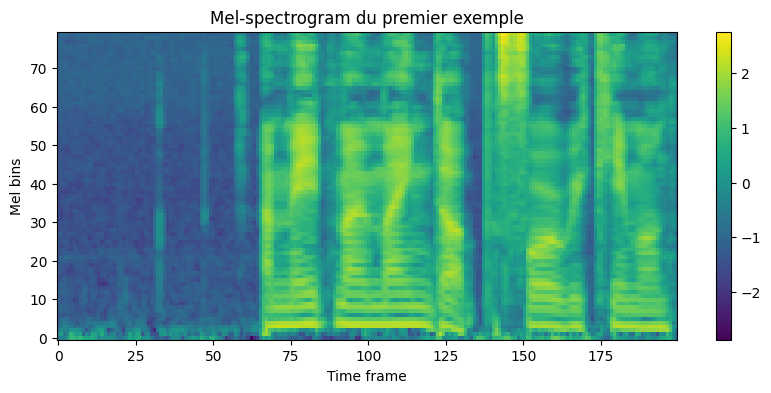

In [12]:
# Récupère le premier batch
batch = next(iter(train_loader))
print("Type du batch:", type(batch))
print("Shape du batch:", batch.shape)

x0 = batch[:, 0, :]   # shape = (seq_len, mel_dim)
print("Shape séquence 0 :", x0.shape)
print(x0)

plt.figure(figsize=(10,4))
plt.imshow(x0.T, aspect="auto", origin="lower")
plt.colorbar()
plt.title("Mel-spectrogram du premier exemple")
plt.xlabel("Time frame")
plt.ylabel("Mel bins")
plt.show()

In [13]:
import os
import sys
# os.chdir("..")
sys.path.append(os.path.abspath(".."))

import json
import torch
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import torchaudio
import glob
from tqdm import tqdm # Import tqdm

from model.VRNN import VRNN
from dataset.audio_dataset import AudioDataset
from utils.padding import collate_fn
from experiments.train import train, evaluate



import os
import json
import torch


def save_checkpoint(state, checkpoint_dir, name="last.pt"):
    os.makedirs(checkpoint_dir, exist_ok=True)
    path = os.path.join(checkpoint_dir, name)
    torch.save(state, path)


def load_checkpoint(model, optimizer, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    start_epoch = checkpoint["epoch"] + 1
    history = checkpoint["history"]
    print(f"Checkpoint loaded from: {checkpoint_path}")
    return start_epoch, history


def evaluate(model, dataloader, device):
    model.eval()
    total_recon, total_kld = 0, 0
    n_batches = 0

    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)              # (batch, seq, feat)
            batch = batch.permute(1, 0, 2)        # → (seq, batch, feat)
            seq_len, batch_size, _ = batch.shape

            recon, kld = model(batch)
            recon = recon / (batch_size * seq_len)
            kld = kld / (batch_size * seq_len)

            total_recon += recon.item()
            total_kld += kld.item()
            n_batches += 1

    return total_recon / n_batches, total_kld / n_batches



def train_model(
    model,
    train_loader,
    val_loader,
    checkpoint_dir="checkpoints",
    resume=False,
    epochs=50,
    batch_size=32,
    lr=1e-4,
    kl_anneal_epochs=10,
    patience=7,
    device="cuda"
):

    device = torch.device(device if torch.cuda.is_available() else "cpu")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Tracking
    history = {
        "train": [],
        "val": [],
        "beta": [],
        "train_recon": [],
        "train_kld": [],
        "val_recon": [],
        "val_kld": []
    }

    start_epoch = 0
    best_val_loss = float("inf")
    patience_counter = 0

    # Resume training
    last_ckpt = os.path.join(checkpoint_dir, "last.pt")
    if resume and os.path.exists(last_ckpt):
        start_epoch, history = load_checkpoint(model, optimizer, last_ckpt, device)
        print(f"Resuming from epoch {start_epoch}")

    # Training loop
    for epoch in range(start_epoch, epochs):
        model.train()
        total_recon, total_kld = 0, 0
        n_batches = 0

        beta = min(1.0, epoch / kl_anneal_epochs)

        # Wrap train_loader with tqdm for a progress bar
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"): # Added tqdm here
            batch = batch.to(device)             # (batch, seq, feat)
            batch = batch.permute(1, 0, 2)       # → (seq, batch, feat)
            seq_len, batch_size, _ = batch.shape

            optimizer.zero_grad()
            recon, kld = model(batch)

            recon = recon / (batch_size * seq_len)
            kld = kld / (batch_size * seq_len)
            loss = recon + beta * kld

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_recon += recon.item()
            total_kld += kld.item()
            n_batches += 1

        train_recon = total_recon / n_batches
        train_kld = total_kld / n_batches
        train_loss = train_recon + beta * train_kld

        # Validation
        val_recon, val_kld = evaluate(model, val_loader, device=device)
        val_loss = val_recon + beta * val_kld

        print(f"[{epoch+1}/{epochs}] "
              f"Train: {train_loss:.3f} | Val: {val_loss:.3f} | β={beta:.3f}")

        # Update history
        history["train"].append(train_loss)
        history["val"].append(val_loss)
        history["beta"].append(beta)
        history["train_recon"].append(train_recon)
        history["train_kld"].append(train_kld)
        history["val_recon"].append(val_recon)
        history["val_kld"].append(val_kld)

        # Save last checkpoint
        save_checkpoint({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history
        }, checkpoint_dir, "last.pt")

        # Save best model
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            save_checkpoint({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "history": history
            }, checkpoint_dir, "best.pt")
            patience_counter = 0
            print(" → Saved BEST model")
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    # Save history as JSON
    with open(os.path.join(checkpoint_dir, "history.json"), "w") as f:
        json.dump(history, f, indent=4)

    print("\nTraining complete.")
    return history



Interpretation: from epoch 10 to 40, the models does not exploit the latent vector z and only relies on the RNN part: this results in a posterior q(z I x) that remains identical to the prior p(z) and a null KL. However, after epoch 40, the model starts using the latent variable z: this results in a decreasing loss but an increase in the KL as q(z I x) changes.

We need to increase the number of epochs and the rate at which parameter beta increases to avoid this phenomenon.

Epoch 1/150 Training: 100%|██████████| 74/74 [00:12<00:00,  5.94it/s]


[1/150] Train: 33.924 | Val: 25.605 | β=0.000
 → Saved BEST model


Epoch 2/150 Training: 100%|██████████| 74/74 [00:11<00:00,  6.46it/s]


[2/150] Train: 11.752 | Val: -3.071 | β=0.100
 → Saved BEST model


Epoch 3/150 Training: 100%|██████████| 74/74 [00:11<00:00,  6.39it/s]


...

[143/150] Train: -48.008 | Val: -46.069 | β=1.000


Epoch 144/150 Training: 100%|██████████| 74/74 [00:11<00:00,  6.48it/s]


[144/150] Train: -48.379 | Val: -45.993 | β=1.000


Epoch 145/150 Training: 100%|██████████| 74/74 [00:11<00:00,  6.54it/s]


[145/150] Train: -48.005 | Val: -46.220 | β=1.000
Early stopping triggered.

Training complete.


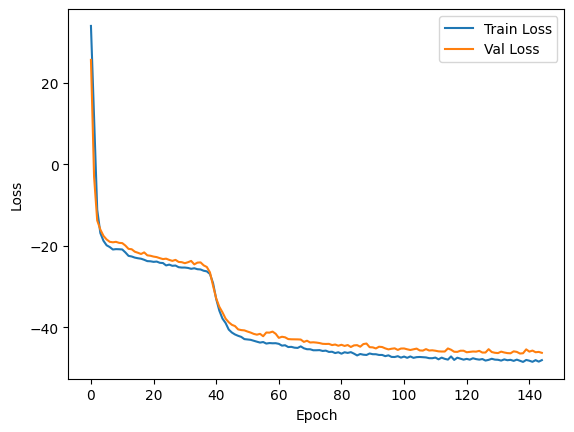

In [14]:
history = train_model(model=model, train_loader=train_loader, val_loader=val_loader,epochs=150,batch_size=32,lr=1e-4,kl_anneal_epochs=10, patience=7,device="cuda")

plt.plot(history['train'], label="Train Loss")
plt.plot(history['val'], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Contenu du JSON :
{'train': [33.924450178404115, 11.751911132384997, -11.111651679631827, -16.856420580116477, -18.756467205769304, -19.853658440950756, -20.28573221967027, -20.886226204279307, -20.797137451171874, -20.823132107547814, -20.87853186356055, -21.60321401583182, -22.44538148673805, -22.598289882814562, -22.87183432643478, -23.031202896221263, -23.146373149510975, -23.409410927746748, -23.73409682673377, -23.774832301848644, -23.913905702732706, -23.844769294197494, -24.147036618477593, -24.205429977661854, -24.790986476717766, -24.58926891636204, -24.8826314178673, -24.813799461802923, -25.224431356868227, -25.31255451086405, -25.311301131506223, -25.40591996747094, -25.620074578233666, -25.48241660723815, -25.716786191270156, -25.780726226600443, -26.097421336818385, -26.24320925570823, -26.883018616083508, -29.13369895316459, -33.01578401874852, -35.87650458232777, -37.822197914123535, -38.908231271279824, -40.51239277865435, -41.239983423336135, -41.71573279355023, -42.

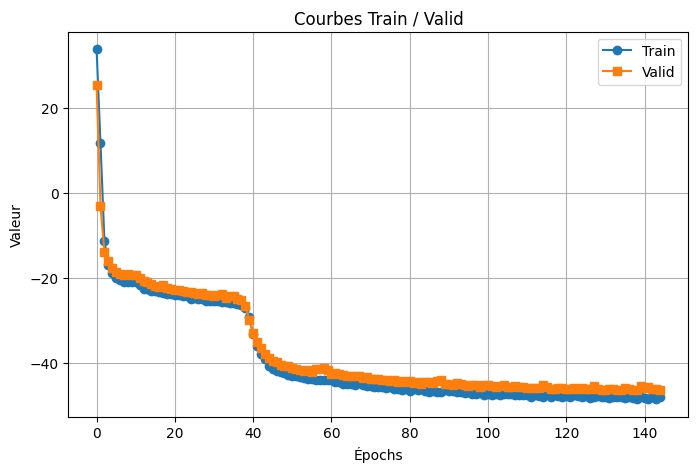

In [15]:
# Chemin vers le fichier JSON (ex: dossier "data")
chemin_fichier = os.path.join("checkpoints", "history.json")

def lire_json(chemin):
    try:
        with open(chemin, "r", encoding="utf-8") as fichier:
            contenu = json.load(fichier)
            return contenu
    except FileNotFoundError:
        print(f"Fichier introuvable : {chemin}")
    except json.JSONDecodeError:
        print("Erreur : le fichier n'est pas un JSON valide.")

# Lecture du contenu
data = lire_json(chemin_fichier)

if data:
    print("Contenu du JSON :")
    print(data)


train = data.get("train")
valid = data.get("val")

# Vérification
if train is None or valid is None:
    raise ValueError("Le fichier JSON doit contenir les clés 'train' et 'valid'")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(train, label="Train", marker="o")
plt.plot(valid, label="Valid", marker="s")

plt.title("Courbes Train / Valid")
plt.xlabel("Épochs")
plt.ylabel("Valeur")
plt.grid(True)
plt.legend()

plt.show()


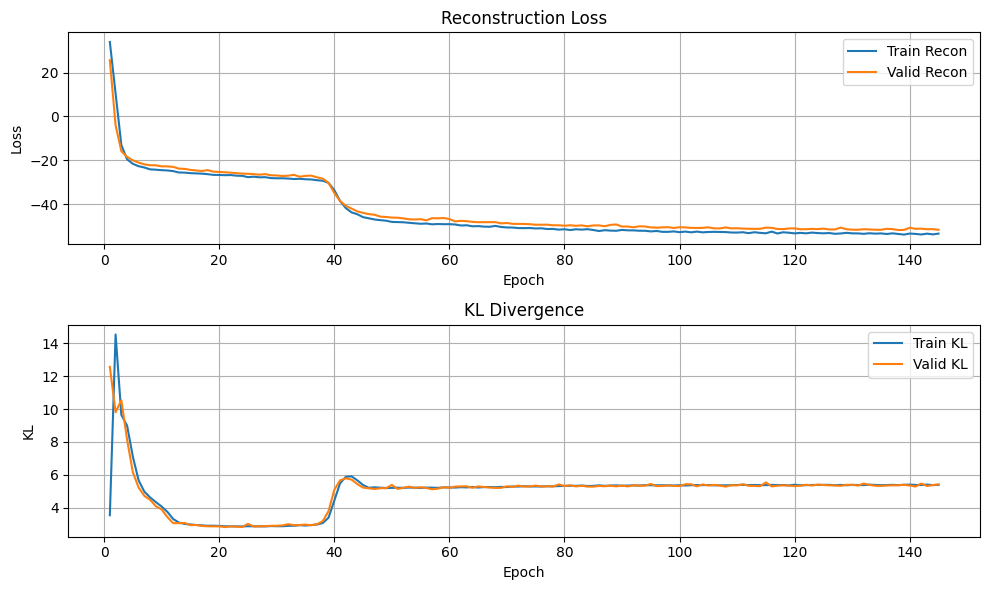

In [16]:
# Charger l'historique
with open("checkpoints/history.json", "r") as f:
    history = json.load(f)

train_recon = history["train_recon"]
train_kld = history["train_kld"]
val_recon = history["val_recon"]
val_kld = history["val_kld"]

epochs = range(1, len(train_recon) + 1)

plt.figure(figsize=(10, 6))

# Reconstruction
plt.subplot(2, 1, 1)
plt.plot(epochs, train_recon, label="Train Recon")
plt.plot(epochs, val_recon, label="Valid Recon")
plt.title("Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# KL Divergence
plt.subplot(2, 1, 2)
plt.plot(epochs, train_kld, label="Train KL")
plt.plot(epochs, val_kld, label="Valid KL")
plt.title("KL Divergence")
plt.xlabel("Epoch")
plt.ylabel("KL")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Initializing a new VRNN model for training from scratch...
New VRNN model initialized.


Epoch 1/150 Training: 100%|██████████| 74/74 [00:11<00:00,  6.42it/s]


[1/150] Train: 34.512 | Val: 28.129 | β=0.000
 → Saved BEST model


Epoch 2/150 Training: 100%|██████████| 74/74 [00:11<00:00,  6.26it/s]


[2/150] Train: 13.359 | Val: -2.256 | β=0.033
 → Saved BEST model


...

[127/150] Train: -47.653 | Val: -45.739 | β=1.000


Epoch 128/150 Training: 100%|██████████| 74/74 [00:11<00:00,  6.50it/s]


[128/150] Train: -47.865 | Val: -46.152 | β=1.000


Epoch 129/150 Training: 100%|██████████| 74/74 [00:11<00:00,  6.45it/s]


[129/150] Train: -47.839 | Val: -46.104 | β=1.000
Early stopping triggered.

Training complete.


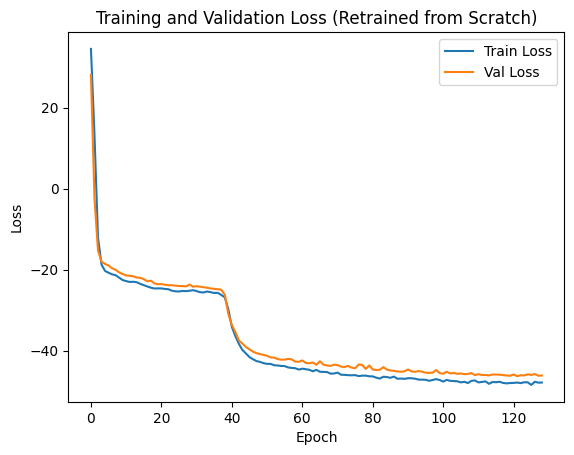

In [17]:
print("Initializing a new VRNN model for training from scratch...")
model_2 = VRNN().to(device)
print("New VRNN model initialized.")

# Call train_model with the newly initialized model
history = train_model(
    model=model_2,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=150, # Using the increased epochs from your previous run
    batch_size=32,
    lr=1e-3,
    kl_anneal_epochs=30,
    patience=7,
    device="cuda",
    resume=False # Explicitly set to False to ensure no checkpoint loading
)

# Plot the training history
plt.plot(history['train'], label="Train Loss")
plt.plot(history['val'], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss (Retrained from Scratch)")
plt.show()

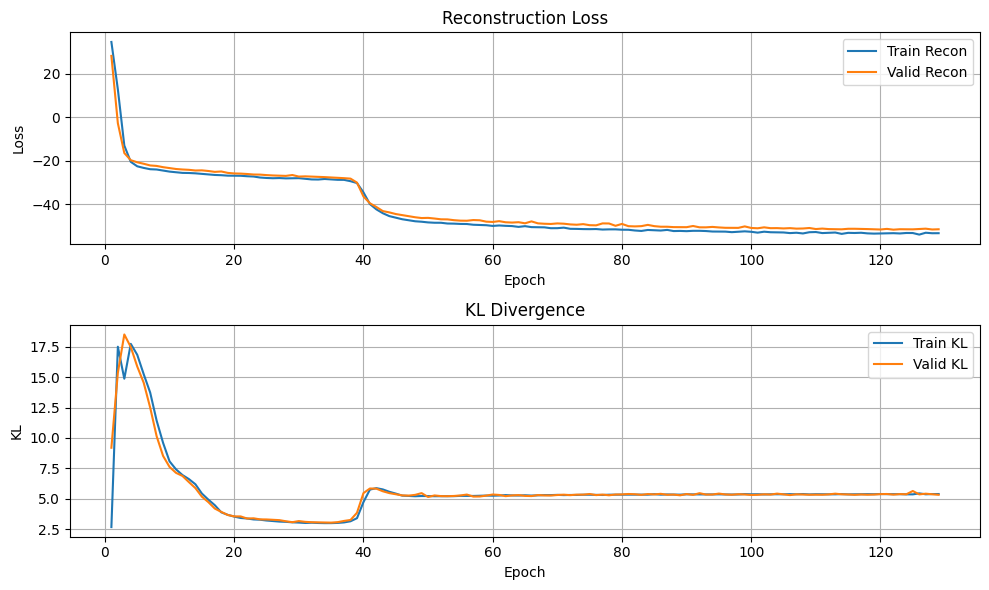

In [18]:
# Charger l'historique
with open("checkpoints/history.json", "r") as f:
    history = json.load(f)

train_recon = history["train_recon"]
train_kld = history["train_kld"]
val_recon = history["val_recon"]
val_kld = history["val_kld"]

epochs = range(1, len(train_recon) + 1)

plt.figure(figsize=(10, 6))

# Reconstruction
plt.subplot(2, 1, 1)
plt.plot(epochs, train_recon, label="Train Recon")
plt.plot(epochs, val_recon, label="Valid Recon")
plt.title("Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# KL Divergence
plt.subplot(2, 1, 2)
plt.plot(epochs, train_kld, label="Train KL")
plt.plot(epochs, val_kld, label="Valid KL")
plt.title("KL Divergence")
plt.xlabel("Epoch")
plt.ylabel("KL")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Generation

In [ ]:
import librosa
import numpy as np

In [ ]:
import torch
import numpy as np
import torchaudio
from torchaudio.transforms import InverseMelScale
from IPython.display import Audio, display


@torch.no_grad()
def generate_and_listen_vrnn_mel(
    vrnn,
    ckpt_path,
    mean,
    std,
    seq_len,
    device="cpu",
    deterministic=False,
    sample_rate=22050,
    n_fft=1024,
    hop_length=256,
    win_length=1024,
    n_mels=80,
    griffin_lim_iters=32
):
    """
    Génère un audio depuis un VRNN entraîné sur mel-spectrogrammes normalisés
    """

    # ---------- Load checkpoint
    ckpt = torch.load(ckpt_path, map_location=device)
    if "model_state" in ckpt:
        vrnn.load_state_dict(ckpt["model_state"])
    else:
        vrnn.load_state_dict(ckpt)

    vrnn.to(device)
    vrnn.eval()

    # ---------- Safety checks
    assert vrnn.x_dim == n_mels, "x_dim ≠ n_mels"
    assert mean.shape[0] == n_mels
    assert std.shape[0] == n_mels

    # ---------- Generate normalized mel
    mel_norm = vrnn.generate(
        seq_len=seq_len,
        batch=1,
        device=device,
        deterministic=deterministic
    )

    mel_norm = mel_norm.squeeze(1).T  # (80, T)

    # ---------- De-normalize
    mean = mean.to(device).unsqueeze(1)
    std = std.to(device).unsqueeze(1)

    mel_db = mel_norm * std + mean

    # ---------- DB → amplitude
    mel = torch.pow(10.0, mel_db / 10.0)

    # ---------- Mel → STFT magnitude
    inv_mel = InverseMelScale(
        n_stft=n_fft // 2 + 1,
        n_mels=n_mels,
        sample_rate=sample_rate
    ).to(device)

    stft_mag = inv_mel(mel)

    # ---------- Griffin-Lim
    waveform = torchaudio.functional.griffinlim(
        stft_mag,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        power=1.0,
        n_iter=griffin_lim_iters
    )

    # ---------- Normalize
    waveform = waveform / (waveform.abs().max() + 1e-8)

    audio = waveform.squeeze().cpu().numpy()

    # ---------- Play
    display(Audio(audio, rate=sample_rate))

    return audio


In [ ]:
def generate_and_listen_vrnn_mel(vrnn, ckpt_path, mean, std, seq_len=400,
                                 deterministic=False, device="cpu",
                                 n_fft=1024, hop_length=256, win_length=1024,
                                 n_iter=32, sample_rate=22050):
    """
    Génère un audio depuis un VRNN entraîné sur mel-spectrogrammes normalisés.
    Retourne un waveform torch.Tensor sur CPU.
    """
    # ----- Charger le checkpoint -----


    # ----- Génération du spectrogramme -----
    with torch.no_grad():
        mel = vrnn.generate(seq_len=seq_len, device=device, deterministic=deterministic).to(device)
        mel = mel * std + mean  # dénormalisation

    # ----- Inverse Mel → STFT -----
    inv_mel = torchaudio.transforms.InverseMelScale(
        n_stft=(n_fft // 2 + 1),
        n_mels=mel.shape[1],
        sample_rate=sample_rate
    )
    stft_mag = inv_mel(mel.T)  # shape: [freq, time]

    # ----- Redimension pour éviter le padding Griffin-Lim -----
    # expected_time = stft_mag.shape[1]
    # if expected_time < n_fft:
    #     stft_mag = F.pad(stft_mag, (0, n_fft - expected_time))

    # # # ----- Griffin-Lim -----
    # window = torch.hann_window(win_length).to(device)
    # waveform_length = stft_mag.shape[1] * hop_length

    # waveform = torchaudio.functional.griffinlim(
    #     specgram=stft_mag,
    #     n_fft=n_fft,
    #     hop_length=hop_length,
    #     win_length=win_length,
    #     window=window,
    #     power=1.0,
    #     n_iter=n_iter,
    #     momentum=0.99,
    #     length=waveform_length,
    #     rand_init=True
    # )

    # # ----- Normalisation finale -----
    # waveform = waveform / (waveform.abs().max() + 1e-8)

    # return waveform.cpu()

    return mel

In [ ]:

import torch.nn.functional as F

In [ ]:
vrnn = VRNN(
    x_dim=80,
    h_dim=256,
    z_dim=32,
    phi_x_dim=32,
    phi_z_dim=16
)

stats = torch.load("mel_stats.pt", map_location="cpu")

mean = stats["mean"]
std = stats["std"]

mel = generate_and_listen_vrnn_mel(
    vrnn=vrnn,
    ckpt_path="checkpoints/best.pt",
    mean=mean,
    std=std,
    seq_len=400,        # ≈ 400 frames
    deterministic=False,
    device="cpu"
)


FileNotFoundError: [Errno 2] No such file or directory: 'mel_stats.pt'

In [ ]:
import matplotlib.pyplot as plt

def plot_mel(mel, title="Mel spectrogram"):
    """
    mel: (T, 80) ou (80, T)
    """
    mel_2d = np.squeeze(mel)  # shape becomes (80, 400)

    plt.figure(figsize=(10, 4))
    plt.imshow(mel_2d, aspect="auto", origin="lower")
    plt.colorbar()
    plt.title("Mel Spectrogram")
    plt.show()


In [ ]:
plot_mel(mel)

NameError: name 'mel' is not defined

In [ ]:
def compare_stats(mel_real, mel_gen):
    print("REAL  mean:", mel_real.mean().item(), "std:", mel_real.std().item())
    print("GEN   mean:", mel_gen.mean().item(), "std:", mel_gen.std().item())


In [ ]:
def temporal_diff_energy(mel):
    diff = mel[1:] - mel[:-1]
    return diff.abs().mean().item()

print("REAL temporal diff:", temporal_diff_energy(mel_real))
print("GEN  temporal diff:", temporal_diff_energy(mel_gen))


NameError: name 'mel_real' is not defined